# 04 — Customer Lifetime Value & Business Profiling
## Home Credit Default Risk Dataset
### Goal: Estimate CLV per segment and generate business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 100)
print('Libraries loaded')

Libraries loaded


In [2]:
# Load segmented customers
df = pd.read_csv('../outputs/segmented_customers.csv')
print('Shape:', df.shape)
print('Segments:', df['Segment'].value_counts())

Shape: (307511, 54)
Segments: Segment
Mass Market Mainstream     222714
Active High Value           58394
Dormant / New Customers     15884
Disciplined Transactors     10519
Name: count, dtype: int64


## CLV Estimation
CLV = Average Payment per Transaction × Transaction Frequency × Credit Quality Score

- Average Payment = TOTAL_PAID / (FREQUENCY + 1)
- Frequency = number of transactions
- Credit Quality = EXT_SOURCE_2 (external credit score proxy)
- Tenure proxy = BUREAU_LOAN_COUNT (number of historical loans)

In [3]:
# CLV Calculation
df['AVG_PAYMENT'] = df['TOTAL_PAID'] / (df['FREQUENCY'] + 1)
df['CLV'] = df['AVG_PAYMENT'] * df['BUREAU_LOAN_COUNT'] * df['EXT_SOURCE_2']

# Clip negative and extreme values
df['CLV'] = df['CLV'].clip(lower=0)
df['CLV'] = df['CLV'].clip(upper=df['CLV'].quantile(0.99))

print('CLV Summary:')
print(df.groupby('Segment')['CLV'].describe().round(2))

CLV Summary:
                            count      mean       std  min      25%      50%  \
Segment                                                                        
Active High Value        58394.00  41877.12  64148.91 0.00  5214.50 18922.03   
Disciplined Transactors  10519.00 115733.57 133382.72 0.00 15200.54 59926.25   
Dormant / New Customers  15884.00     10.31   1214.42 0.00     0.00     0.00   
Mass Market Mainstream  222714.00  41463.22  68515.89 0.00  4736.58 17592.72   

                              75%       max  
Segment                                      
Active High Value        49922.41 435520.51  
Disciplined Transactors 170330.81 435520.51  
Dormant / New Customers      0.00 152912.31  
Mass Market Mainstream   46385.11 435520.51  


In [4]:
# Average CLV per segment
clv_summary = df.groupby('Segment').agg(
    Customer_Count = ('SK_ID_CURR', 'count'),
    Avg_CLV = ('CLV', 'mean'),
    Median_CLV = ('CLV', 'median'),
    Total_CLV = ('CLV', 'sum'),
    Avg_Income = ('AMT_INCOME_TOTAL', 'mean'),
    Avg_Credit = ('AMT_CREDIT', 'mean'),
    Avg_Frequency = ('FREQUENCY', 'mean'),
    Avg_TotalPaid = ('TOTAL_PAID', 'mean'),
    Avg_PaymentDiscipline = ('PAYMENT_DISCIPLINE', 'mean'),
    Avg_LatePayments = ('LATE_PAYMENT_COUNT', 'mean')
).round(2)

print(clv_summary.T)

Segment                Active High Value  Disciplined Transactors  \
Customer_Count                  58394.00                 10519.00   
Avg_CLV                         41877.12                115733.57   
Median_CLV                      18922.03                 59926.25   
Total_CLV                  2445372282.87            1217401424.64   
Avg_Income                     178459.46                184594.47   
Avg_Credit                     620977.50                656009.76   
Avg_Frequency                      90.24                    27.90   
Avg_TotalPaid                 1260703.51               1357312.39   
Avg_PaymentDiscipline               1.03                    22.76   
Avg_LatePayments                    6.13                     1.28   

Segment                Dormant / New Customers  Mass Market Mainstream  
Customer_Count                        15884.00               222714.00  
Avg_CLV                                  10.31                41463.22  
Median_CLV           

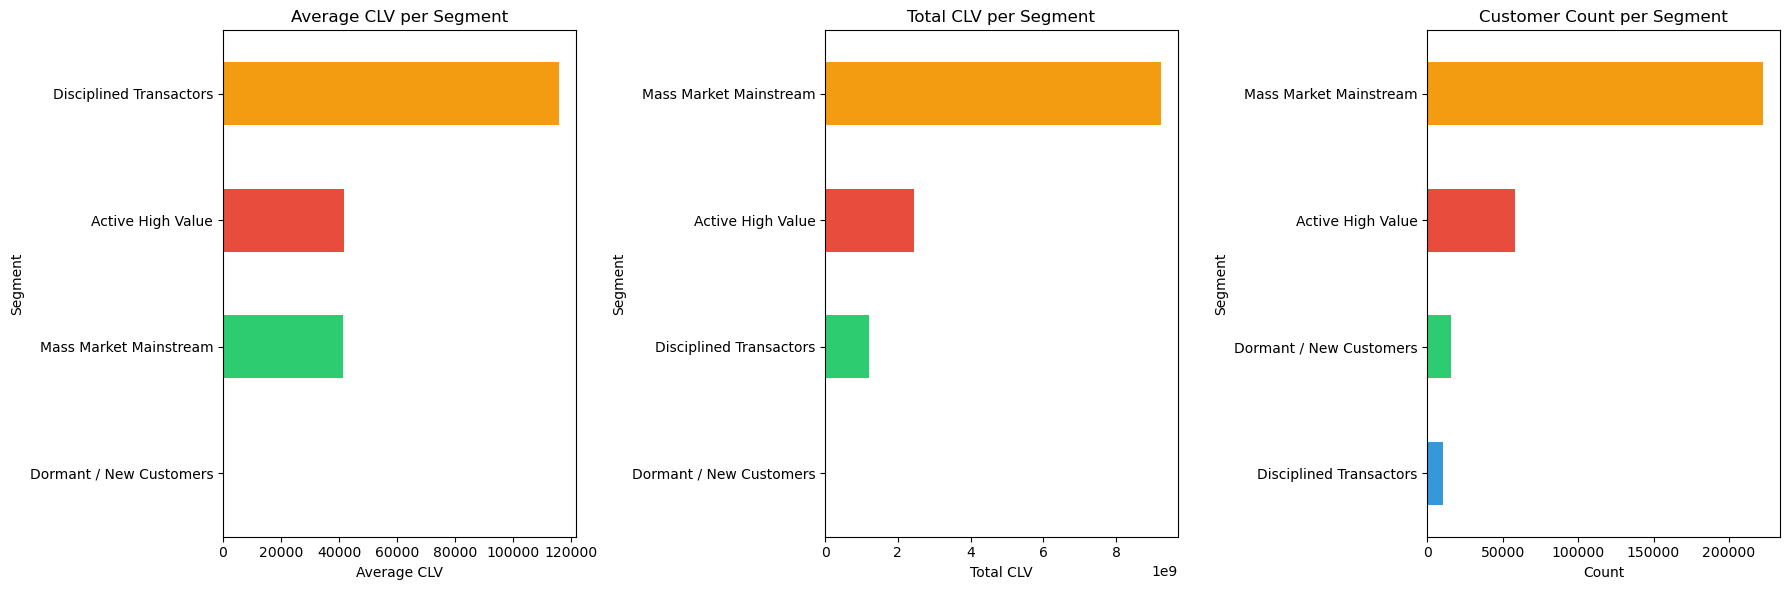

In [5]:
# CLV by Segment - Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Average CLV
clv_summary['Avg_CLV'].sort_values().plot(
    kind='barh', ax=axes[0], color=colors
)
axes[0].set_title('Average CLV per Segment')
axes[0].set_xlabel('Average CLV')

# Total CLV
clv_summary['Total_CLV'].sort_values().plot(
    kind='barh', ax=axes[1], color=colors
)
axes[1].set_title('Total CLV per Segment')
axes[1].set_xlabel('Total CLV')

# Customer Count
clv_summary['Customer_Count'].sort_values().plot(
    kind='barh', ax=axes[2], color=colors
)
axes[2].set_title('Customer Count per Segment')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('../outputs/clv_summary.png', dpi=150)
plt.show()

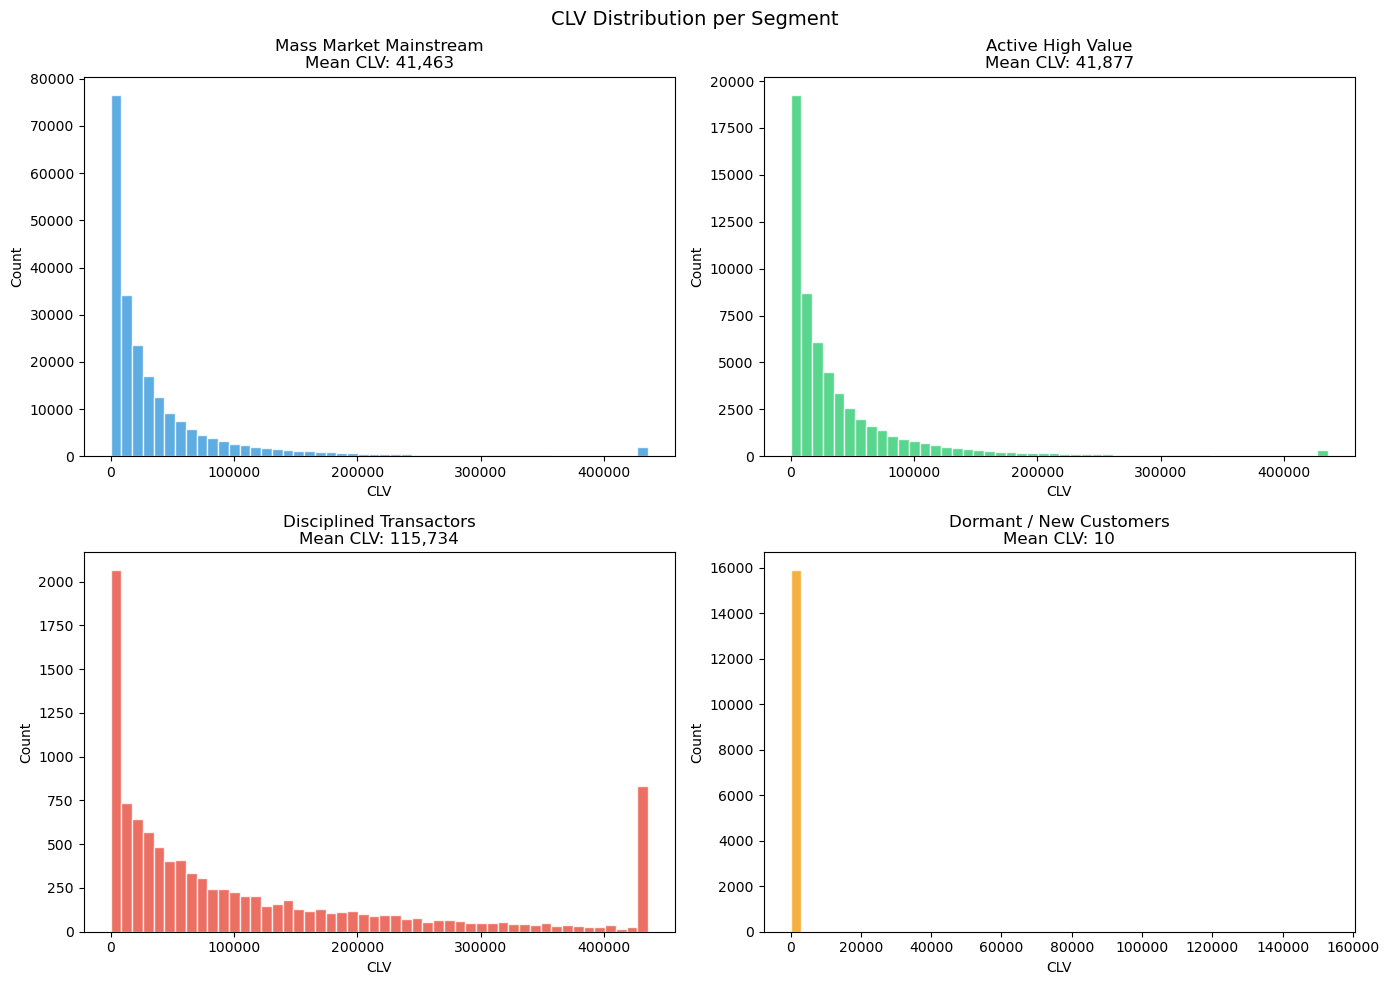

In [6]:
# CLV Distribution per Segment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
segments = df['Segment'].unique()

for i, seg in enumerate(segments):
    subset = df[df['Segment'] == seg]['CLV']
    axes[i].hist(subset, bins=50, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{seg}\nMean CLV: {subset.mean():,.0f}')
    axes[i].set_xlabel('CLV')
    axes[i].set_ylabel('Count')

plt.suptitle('CLV Distribution per Segment', size=14)
plt.tight_layout()
plt.savefig('../outputs/clv_distribution.png', dpi=150)
plt.show()

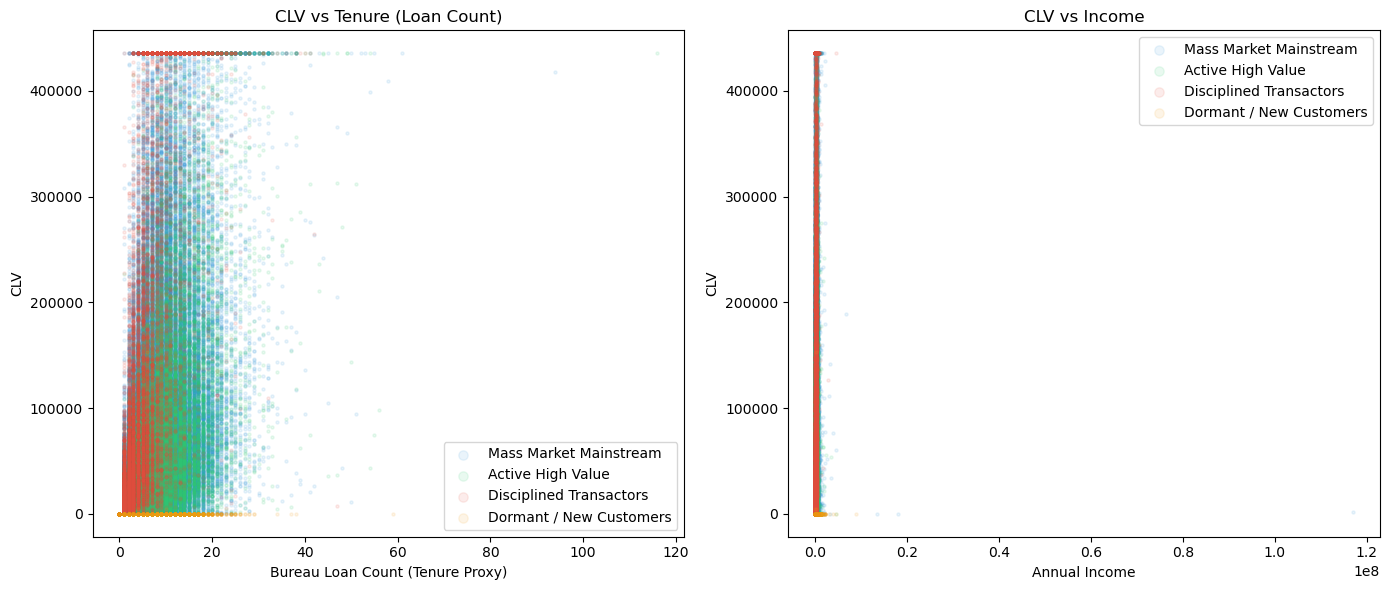

In [7]:
# CLV vs Tenure (Bureau Loan Count as proxy)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, seg in enumerate(segments):
    subset = df[df['Segment'] == seg]
    axes[0].scatter(
        subset['BUREAU_LOAN_COUNT'],
        subset['CLV'],
        alpha=0.1, s=5, color=colors[i], label=seg
    )

axes[0].set_title('CLV vs Tenure (Loan Count)')
axes[0].set_xlabel('Bureau Loan Count (Tenure Proxy)')
axes[0].set_ylabel('CLV')
axes[0].legend(markerscale=3)

# CLV vs Income
for i, seg in enumerate(segments):
    subset = df[df['Segment'] == seg]
    axes[1].scatter(
        subset['AMT_INCOME_TOTAL'],
        subset['CLV'],
        alpha=0.1, s=5, color=colors[i], label=seg
    )

axes[1].set_title('CLV vs Income')
axes[1].set_xlabel('Annual Income')
axes[1].set_ylabel('CLV')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig('../outputs/clv_vs_tenure_income.png', dpi=150)
plt.show()

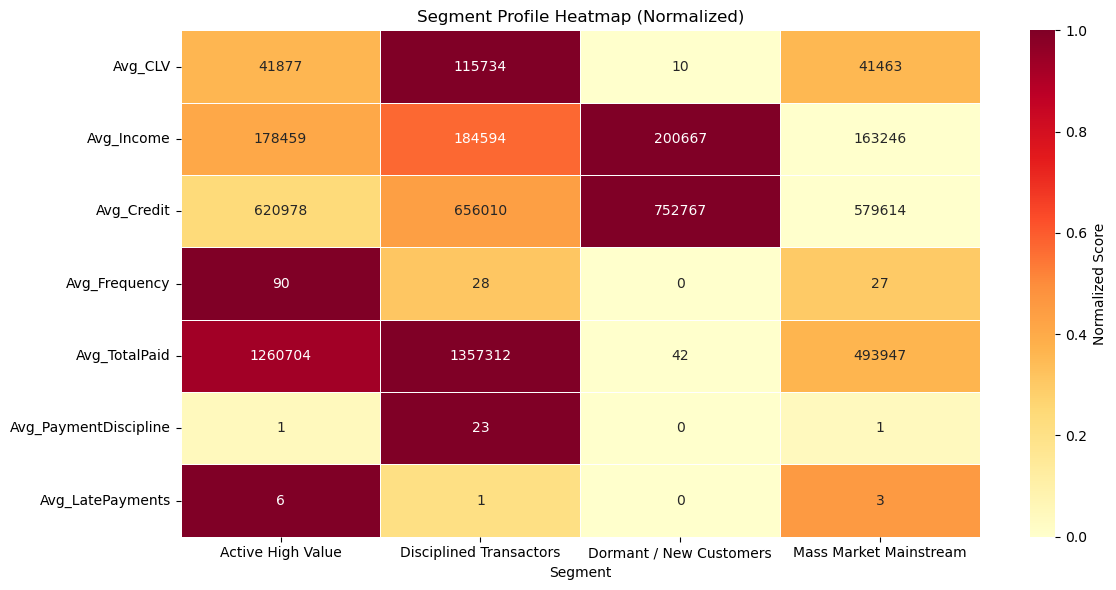

In [8]:
# Heatmap of segment profiles
profile_cols = [
    'Avg_CLV', 'Avg_Income', 'Avg_Credit',
    'Avg_Frequency', 'Avg_TotalPaid',
    'Avg_PaymentDiscipline', 'Avg_LatePayments'
]

heatmap_data = clv_summary[profile_cols].copy()
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_norm.T,
    annot=heatmap_data.T.round(0),
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Normalized Score'}
)
plt.title('Segment Profile Heatmap (Normalized)')
plt.tight_layout()
plt.savefig('../outputs/segment_heatmap.png', dpi=150)
plt.show()

## Business Recommendations per Segment

### 1. Active High Value
- **Priority:** Retention — highest CLV, highest transaction frequency
- **Strategy:** Loyalty rewards, premium credit card upgrades, relationship manager assignment
- **Risk:** High CC balance — monitor utilization ratio quarterly
- **Marketing:** Cross-sell wealth management, insurance, and investment products

### 2. Disciplined Transactors
- **Priority:** Upsell — excellent payment behavior, low late payments
- **Strategy:** Offer higher credit limits, premium loan products at preferential rates
- **Risk:** Low — most reliable payers in the portfolio
- **Marketing:** Home loans, auto loans, education loans — they will repay

### 3. Mass Market Mainstream
- **Priority:** Engagement — largest segment, moderate activity
- **Strategy:** Digital engagement campaigns, auto-debit enrollment, savings product bundling
- **Risk:** Medium — monitor for early delinquency signals
- **Marketing:** Personal loans, credit cards with cashback, EMI offers

### 4. Dormant / New Customers
- **Priority:** Activation — zero transaction activity, high churn risk
- **Strategy:** Onboarding campaigns, first transaction incentives, branch outreach
- **Risk:** Unknown — no behavioral history to assess
- **Marketing:** Starter credit cards, small personal loans to build history

In [9]:
# Final CLV ranking table
final_table = clv_summary[[
    'Customer_Count', 'Avg_CLV', 'Total_CLV',
    'Avg_Income', 'Avg_Frequency', 'Avg_LatePayments'
]].sort_values('Avg_CLV', ascending=False)

final_table.columns = [
    'Customers', 'Avg CLV', 'Total CLV',
    'Avg Income', 'Avg Frequency', 'Avg Late Payments'
]

print('=== FINAL SEGMENT RANKING BY CLV ===')
print(final_table.to_string())

=== FINAL SEGMENT RANKING BY CLV ===
                         Customers   Avg CLV     Total CLV  Avg Income  Avg Frequency  Avg Late Payments
Segment                                                                                                 
Disciplined Transactors      10519 115733.57 1217401424.64   184594.47          27.90               1.28
Active High Value            58394  41877.12 2445372282.87   178459.46          90.24               6.13
Mass Market Mainstream      222714  41463.22 9234439206.72   163245.76          27.07               2.79
Dormant / New Customers      15884     10.31     163787.46   200666.70           0.04               0.00


## Project Summary

| Notebook | Content |
|---|---|
| 01_eda | Data loading, cleaning, missing value treatment |
| 02_feature_engineering | RFM from 5 source files, behavioral features |
| 03_clustering | PCA, KMeans, GMM, Hierarchical, DBSCAN comparison |
| 04_clv_profiling | CLV estimation, segment profiling, business recommendations |

### Key Results
- **307,511** real customers from Home Credit Group
- **51 features** engineered from 5 source files
- **Silhouette Score: 0.64** after log transformation and RobustScaler
- **ARI KMeans vs Hierarchical: 0.95** — near perfect method agreement
- **GMM Confidence: 98.9%** — high certainty soft assignments
- **4 actionable segments** with distinct CLV profiles and marketing strategies